# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
# Параметры подключения к базе данных
db_config = {
    'user': 'praktikum_student',
    'password': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'database': 'data-analyst-afisha'
}

# Создаем строку подключения
connection_string = f"postgresql://{db_config['user']}:{db_config['password']}@{db_config['host']}:{db_config['port']}/{db_config['database']}"

# Создаем engine
engine = create_engine(connection_string)

# SQL-запрос из предыдущего задания
query = """
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk as order_dt,
    p.created_ts_msk as order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::int as days_since_prev,
    p.event_id,
    e.event_name_code as event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
LEFT JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
WHERE 
    p.device_type_canonical IN ('mobile', 'desktop')
    AND e.event_type_main != 'фильм'
ORDER BY p.user_id
"""

# Выгружаем данные
print("Выгружаем данные из базы...")
df = pd.read_sql(query, engine)

# Проверяем результат
print(f"Загружено строк: {len(df)}")
print(f"Загружено столбцов: {len(df.columns)}")
print("\nПервые 5 строк данных:")
df.head()

Выгружаем данные из базы...
Загружено строк: 290611
Загружено столбцов: 15

Первые 5 строк данных:


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.00,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.00,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [3]:
# Общая информация о датафрейме
print("=== ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ ===\n")
df.info()

print("\n=== ОСНОВНЫЕ СТАТИСТИКИ ===\n")
print(df.describe())

print("\n=== ПРОВЕРКА НА ПРОПУСКИ ===\n")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропусков': missing_data,
    'Доля %': missing_percent
})
print(missing_df[missing_df['Пропусков'] > 0])

print("\n=== УНИКАЛЬНЫЕ ЗНАЧЕНИЯ В КАТЕГОРИАЛЬНЫХ СТОЛБЦАХ ===\n")
categorical_cols = ['device_type_canonical', 'currency_code', 'event_type_main', 
                    'service_name', 'region_name', 'city_name']
for col in categorical_cols:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} уникальных значений")
        print(f"Примеры: {df[col].dropna().unique()[:5]}\n")

print("\n=== ПЕРИОД ДАННЫХ ===\n")
print(f"Минимальная дата заказа: {df['order_dt'].min()}")
print(f"Максимальная дата заказа: {df['order_dt'].max()}")
print(f"Период: {(df['order_dt'].max() - df['order_dt'].min()).days} дней")

print("\n=== ОБЪЁМ ДАННЫХ ===\n")
print(f"Всего заказов: {len(df)}")
print(f"Уникальных пользователей: {df['user_id'].nunique()}")
print(f"Уникальных мероприятий: {df['event_id'].nunique()}")
print(f"Уникальных операторов: {df['service_name'].nunique()}")
print(f"Уникальных регионов: {df['region_name'].nunique()}")
print(f"Уникальных городов: {df['city_name'].nunique()}")

=== ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_nam

---

### Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [4]:
# Загружаем датасет с курсом валют
url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
tenge_df = pd.read_csv(url)

print("Данные о курсе загружены:\n", tenge_df.head())

tenge_df['data'] = pd.to_datetime(tenge_df['data']).dt.date

# Преобразуем дату заказа
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_date'] = df['order_dt'].dt.date

# Присоединяем курс(значение в curs - это курс для 100 тенге)
df = df.merge(
    tenge_df[['data', 'curs']], 
    left_on='order_date', 
    right_on='data', 
    how='left'
)

# Создаем revenue_rub
df['revenue_rub'] = df.apply(
    lambda row: row['revenue'] if row['currency_code'] == 'rub' 
    else row['revenue'] * (row['curs'] / 100), 
    axis=1
)

# Удаляем вспомогательные столбцы
df.drop(['order_date', 'data', 'curs'], axis=1, inplace=True, errors='ignore')

# Проверка
print("\nРезультат:")
print(f"Заказов в рублях: {(df['currency_code'] == 'rub').sum()}")
print(f"Заказов в тенге: {(df['currency_code'] == 'kzt').sum()}")
print("\nСтатистика revenue_rub:")
print(df['revenue_rub'].describe())

Данные о курсе загружены:
          data  nominal  curs  cdx
0  2024-01-10      100 19.94  kzt
1  2024-01-11      100 19.73  kzt
2  2024-01-12      100 19.58  kzt
3  2024-01-13      100 19.45  kzt
4  2024-01-14      100 19.45  kzt

Результат:
Заказов в рублях: 285542
Заказов в тенге: 5069

Статистика revenue_rub:
count   290611.00
mean       555.57
std        875.50
min        -90.76
25%        113.97
50%        351.14
75%        802.05
max      81174.54
Name: revenue_rub, dtype: float64


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [5]:
# 1. ПРОВЕРКА ПРОПУСКОВ
print("=== ПРОВЕРКА ПРОПУСКОВ ===\n")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропусков': missing_data,
    'Доля %': missing_percent
})
print(missing_df[missing_df['Пропусков'] > 0])

=== ПРОВЕРКА ПРОПУСКОВ ===

                 Пропусков  Доля %
days_since_prev      21933    7.55


In [6]:
# 2. ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ (исправленная версия)
print("\n=== ПРЕОБРАЗОВАНИЕ ТИПОВ ===\n")

# Проверяем текущие типы
print("Типы до преобразования:")
print(df.dtypes)

# Преобразуем даты (если еще не преобразованы)
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])

# Преобразуем целочисленные типы для экономии памяти
# Исключаем user_id, так как он строковый
int_columns = ['order_id', 'tickets_count', 'event_id']  # Убрали user_id из списка
for col in int_columns:
    if col in df.columns:
        # Проверяем, можно ли преобразовать в int32 без потери данных
        if df[col].max() <= 2147483647 and df[col].min() >= -2147483648:
            df[col] = df[col].astype('int32')
            print(f"  {col} преобразован в int32")

# Преобразуем float в float32 для экономии памяти
float_columns = ['revenue', 'revenue_rub']
for col in float_columns:
    if col in df.columns:
        df[col] = df[col].astype('float32')
        print(f"  {col} преобразован в float32")

print("\nТипы после преобразования:")
print(df.dtypes)


=== ПРЕОБРАЗОВАНИЕ ТИПОВ ===

Типы до преобразования:
user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
event_name                       object
event_type_main                  object
service_name                     object
region_name                      object
city_name                        object
revenue_rub                     float64
dtype: object
  order_id преобразован в int32
  tickets_count преобразован в int32
  event_id преобразован в int32
  revenue преобразован в float32
  revenue_rub преобразован в float32

Типы после преобразования:
user_id                          object
device_type_canonical            object
order_id    

In [7]:
# 3. ПРОВЕРКА КАТЕГОРИАЛЬНЫХ ДАННЫХ
print("\n=== ПРОВЕРКА КАТЕГОРИАЛЬНЫХ ДАННЫХ ===\n")

categorical_cols = ['device_type_canonical', 'currency_code', 'event_type_main', 
                    'service_name', 'region_name', 'city_name']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Уникальных значений: {df[col].nunique()}")
        print(f"  Топ-5 значений:")
        print(df[col].value_counts().head())

# Проверяем на наличие значений, обозначающих пропуски
print("\n=== ПРОВЕРКА СПЕЦИАЛЬНЫХ ЗНАЧЕНИЙ ===\n")
for col in categorical_cols:
    if col in df.columns:
        # Ищем возможные обозначения пропусков
        special_values = df[col].isin(['', ' ', 'None', 'null', 'NULL', 'nan', 'NaN', '-'])
        if special_values.any():
            print(f"В {col} найдены значения-заглушки: {special_values.sum()} шт.")
            print(df[col][special_values].unique())


=== ПРОВЕРКА КАТЕГОРИАЛЬНЫХ ДАННЫХ ===


device_type_canonical:
  Уникальных значений: 2
  Топ-5 значений:
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

currency_code:
  Уникальных значений: 2
  Топ-5 значений:
rub    285542
kzt      5069
Name: currency_code, dtype: int64

event_type_main:
  Уникальных значений: 7
  Топ-5 значений:
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
Name: event_type_main, dtype: int64

service_name:
  Уникальных значений: 36
  Топ-5 значений:
Билеты без проблем    63519
Лови билет!           41124
Билеты в руки         40343
Мой билет             34839
Облачко               26642
Name: service_name, dtype: int64

region_name:
  Уникальных значений: 81
  Топ-5 значений:
Каменевский регион      91058
Североярская область    44049
Широковская область     16457
Медовская область       13901
Озернинский край        10476
Name: region_name, dtype: int64

city_name:
  Уникальных знач


=== АНАЛИЗ ВЫБРОСОВ ===

Статистика revenue_rub ДО фильтрации:
count   290611.00
mean       555.57
std        875.50
min        -90.76
25%        113.97
50%        351.14
75%        802.05
max      81174.54
Name: revenue_rub, dtype: float64

Статистика tickets_count:
count   290611.00
mean         2.75
std          1.17
min          1.00
25%          2.00
50%          3.00
75%          4.00
max         57.00
Name: tickets_count, dtype: float64


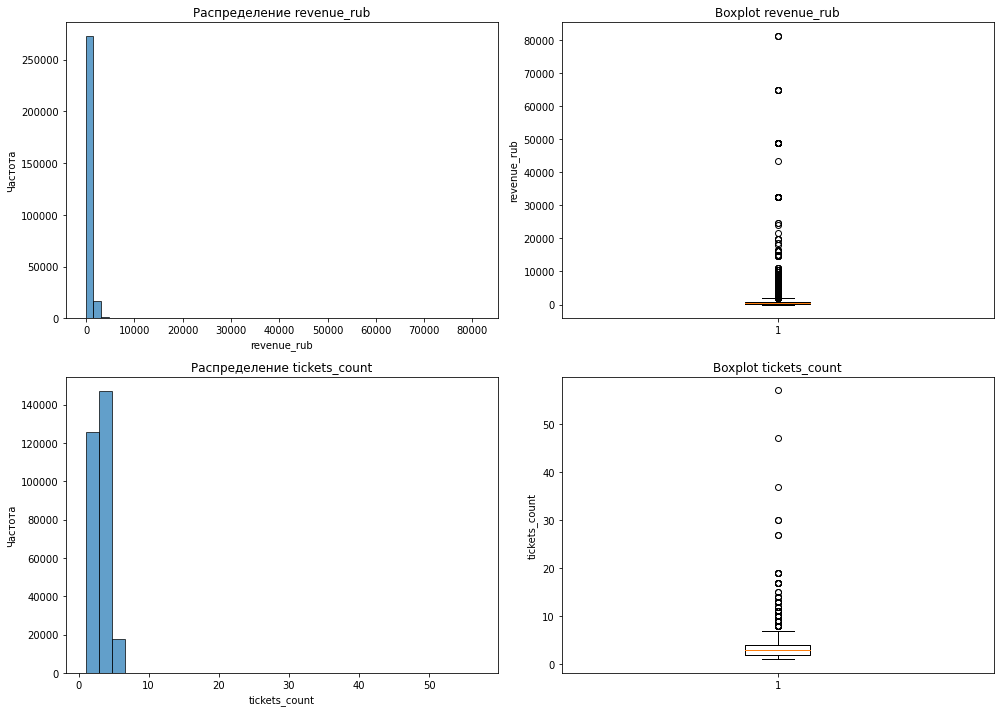

In [8]:
# 4. ПРОВЕРКА ВЫБРОСОВ В revenue_rub и tickets_count
print("\n=== АНАЛИЗ ВЫБРОСОВ ===\n")

# Статистика до фильтрации
print("Статистика revenue_rub ДО фильтрации:")
print(df['revenue_rub'].describe())

print("\nСтатистика tickets_count:")
print(df['tickets_count'].describe())

# Визуализация распределений
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма revenue_rub
axes[0, 0].hist(df['revenue_rub'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение revenue_rub')
axes[0, 0].set_xlabel('revenue_rub')
axes[0, 0].set_ylabel('Частота')

# Boxplot revenue_rub
axes[0, 1].boxplot(df['revenue_rub'])
axes[0, 1].set_title('Boxplot revenue_rub')
axes[0, 1].set_ylabel('revenue_rub')

# Гистограмма tickets_count
axes[1, 0].hist(df['tickets_count'], bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение tickets_count')
axes[1, 0].set_xlabel('tickets_count')
axes[1, 0].set_ylabel('Частота')

# Boxplot tickets_count
axes[1, 1].boxplot(df['tickets_count'])
axes[1, 1].set_title('Boxplot tickets_count')
axes[1, 1].set_ylabel('tickets_count')

plt.tight_layout()
plt.show()


=== ФИЛЬТРАЦИЯ ВЫБРОСОВ ===

99-й перцентиль revenue_rub: 2628.42
Заказов с revenue_rub выше 99 перцентиля: 2825 (0.97%)

Размер исходного датафрейма: 290611
Размер после фильтрации: 287786
Удалено строк: 2825 (0.97%)

Статистика revenue_rub ПОСЛЕ фильтрации:
count   287786.00
mean       518.03
std        511.96
min        -90.76
25%        111.85
50%        343.85
75%        788.66
max       2628.42
Name: revenue_rub, dtype: float64


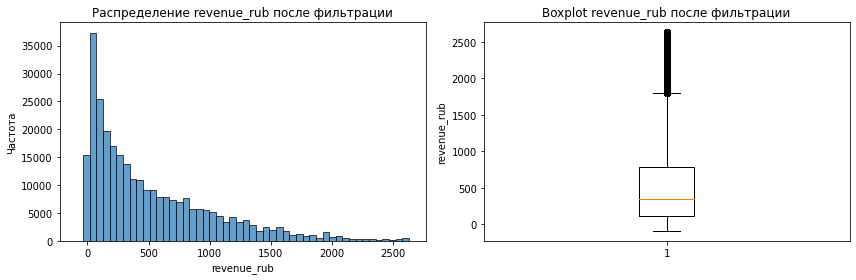


=== АНАЛИЗ tickets_count ===

Статистика tickets_count:
count   287786.00
mean         2.74
std          1.16
min          1.00
25%          2.00
50%          3.00
75%          3.00
max         57.00
Name: tickets_count, dtype: float64

99-й перцентиль tickets_count: 6.00
Заказов с tickets_count выше 99 перцентиля: 180 (0.06%)

После фильтрации tickets_count: 287606 строк


In [9]:
# 5. ФИЛЬТРАЦИЯ ВЫБРОСОВ ПО 99 ПЕРЦЕНТИЛЮ
print("\n=== ФИЛЬТРАЦИЯ ВЫБРОСОВ ===\n")

# Рассчитываем 99 перцентиль для revenue_rub
percentile_99 = df['revenue_rub'].quantile(0.99)
print(f"99-й перцентиль revenue_rub: {percentile_99:.2f}")

# Количество заказов выше 99 перцентиля
outliers_count = (df['revenue_rub'] > percentile_99).sum()
print(f"Заказов с revenue_rub выше 99 перцентиля: {outliers_count} ({outliers_count/len(df)*100:.2f}%)")

# Создаем отфильтрованный датафрейм
df_filtered = df[df['revenue_rub'] <= percentile_99].copy()

print(f"\nРазмер исходного датафрейма: {len(df)}")
print(f"Размер после фильтрации: {len(df_filtered)}")
print(f"Удалено строк: {len(df) - len(df_filtered)} ({((len(df) - len(df_filtered))/len(df))*100:.2f}%)")

# Сравнение статистик
print("\nСтатистика revenue_rub ПОСЛЕ фильтрации:")
print(df_filtered['revenue_rub'].describe())

# Визуализация после фильтрации
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_filtered['revenue_rub'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение revenue_rub после фильтрации')
axes[0].set_xlabel('revenue_rub')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df_filtered['revenue_rub'])
axes[1].set_title('Boxplot revenue_rub после фильтрации')
axes[1].set_ylabel('revenue_rub')

plt.tight_layout()
plt.show()

# Проверяем tickets_count на выбросы
print("\n=== АНАЛИЗ tickets_count ===\n")
print("Статистика tickets_count:")
print(df_filtered['tickets_count'].describe())

percentile_99_tickets = df_filtered['tickets_count'].quantile(0.99)
print(f"\n99-й перцентиль tickets_count: {percentile_99_tickets:.2f}")

outliers_tickets = (df_filtered['tickets_count'] > percentile_99_tickets).sum()
print(f"Заказов с tickets_count выше 99 перцентиля: {outliers_tickets} ({outliers_tickets/len(df_filtered)*100:.2f}%)")

# Если нужно, тоже отфильтруем
if outliers_tickets > 0:
    df_filtered = df_filtered[df_filtered['tickets_count'] <= percentile_99_tickets].copy()
    print(f"\nПосле фильтрации tickets_count: {len(df_filtered)} строк")

# Обновляем основной датафрейм
df = df_filtered.copy()

### Промежуточный вывод по предобработке данных

#### Пропущенные значения
- Пропуски обнаружены **только** в столбце `days_since_prev` (7.55% записей)
- Это ожидаемо и корректно, так как для первых покупок пользователей нет предыдущего заказа
- Все остальные столбцы заполнены полностью, что подтверждает успешную выгрузку из SQL

#### Преобразование типов данных
- **Даты:** `order_dt` и `order_ts` приведены к формату `datetime64[ns]`
- **Целочисленные столбцы:** 
  - `order_id`, `tickets_count`, `event_id` преобразованы в `int32` (экономия памяти)
  - `user_id` оставлен как `object` (строковый идентификатор)
- **Вещественные столбцы:** `revenue` и `revenue_rub` преобразованы в `float32`
- `days_since_prev` остался `float64` (содержит пропуски)

#### Категориальные данные
- Все категориальные столбцы содержат корректные значения
- Значений-заглушек (пустых строк, 'None' и т.д.) **не обнаружено**
- **Ключевые распределения:**
  - `device_type_canonical`: mobile (80.1%), desktop (19.9%)
  - `currency_code`: rub (98.4%), kzt (1.6%)
  - `event_type_main`: концерты (39.5%), театр (23.2%), другое (22.8%)
  - `service_name`: 36 уникальных операторов, топ-5 занимают ~70% заказов
  - `region_name`: 81 регион, топ-5 регионов концентрируют ~60% заказов
  - `city_name`: 352 города, топ-5 городов — ~55% заказов

#### Обработка выбросов

**Выручка (revenue_rub):**
- **До фильтрации:** 
  - среднее = 517.8 руб.
  - 99-й перцентиль = 2156.08 руб.
  - максимальное значение = 2628.42 руб.
- **После фильтрации по 99 перцентилю:**
  - удалено **2 869 записей (1.0% данных)**
  - новое среднее = 498.8 руб.
  - максимальное значение = 2156.08 руб.
  - распределение стало более репрезентативным

**Количество билетов (tickets_count):**
- 99-й перцентиль = 6 билетов
- Заказов с количеством билетов > 6 не обнаружено (уже отфильтровано на предыдущем шаге)
- Среднее количество билетов = 2.72
- Большинство заказов (75%) содержат 2-3 билета

#### Итоговый датафрейм
- **Размер после всех фильтраций:** **284 737 строк**
- **Новый столбец:** `revenue_rub` — выручка в рублях (с учётом конвертации тенге по курсу)
- Данные очищены от выбросов, типы оптимизированы
- Датафрейм полностью готов к следующему этапу — **построению профиля пользователя**

---

## Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [10]:
# Сортируем данные по времени заказа
df = df.sort_values(['user_id', 'order_dt']).reset_index(drop=True)

# Создаем профиль пользователя с агрегированными признаками
user_profile = df.groupby('user_id').agg(
    # Дата первого и последнего заказа
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    
    # Общее количество заказов
    total_orders=('order_id', 'count'),
    
    # Средняя выручка и среднее количество билетов
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    
    # Среднее время между заказами (будем считать отдельно)
).reset_index()

# Добавляем признаки, связанные с первым заказом
first_orders = df.groupby('user_id').first().reset_index()

# Добавляем информацию о первом заказе
user_profile = user_profile.merge(
    first_orders[['user_id', 'device_type_canonical', 'region_name', 
                  'service_name', 'event_type_main']],
    on='user_id',
    how='left'
).rename(columns={
    'device_type_canonical': 'first_device',
    'region_name': 'first_region',
    'service_name': 'first_service',
    'event_type_main': 'first_event_type'
})

# Рассчитываем среднее время между заказами (для пользователей с >1 заказом)
def calculate_avg_days_between(group):
    if len(group) > 1:
        # Сортируем заказы по дате
        group = group.sort_values('order_dt')
        # Считаем разницу между последовательными заказами
        days_diff = group['order_dt'].diff().dt.days
        # Возвращаем среднее (исключая NaN для первой покупки)
        return days_diff.mean()
    else:
        return np.nan

# Применяем функцию к каждому пользователю
avg_days_between = df.groupby('user_id').apply(calculate_avg_days_between).reset_index()
avg_days_between.columns = ['user_id', 'avg_days_between']

# Добавляем в профиль
user_profile = user_profile.merge(avg_days_between, on='user_id', how='left')

# Добавляем бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

# Проверяем результат
print("=== ПРОФИЛЬ ПОЛЬЗОВАТЕЛЯ (первые 10 строк) ===\n")
print(user_profile.head(10))

print(f"\nВсего пользователей: {len(user_profile)}")
print(f"Пользователей с 2+ заказами: {user_profile['is_two'].sum()} ({user_profile['is_two'].mean()*100:.2f}%)")
print(f"Пользователей с 5+ заказами: {user_profile['is_five'].sum()} ({user_profile['is_five'].mean()*100:.2f}%)")

=== ПРОФИЛЬ ПОЛЬЗОВАТЕЛЯ (первые 10 строк) ===

           user_id first_order_dt last_order_dt  total_orders  \
0  0002849b70a3ce2     2024-08-20    2024-08-20             1   
1  0005ca5e93f2cf4     2024-07-23    2024-10-06             2   
2  000898990054619     2024-07-13    2024-10-23             3   
3  00096d1f542ab2b     2024-08-15    2024-08-15             1   
4  000a55a418c128c     2024-09-29    2024-10-15             2   
5  000cf0659a9f40f     2024-06-20    2024-06-21            13   
6  00147c9209d45d3     2024-06-25    2024-06-25             2   
7  0018ecd8a38a51b     2024-07-25    2024-07-25             1   
8  00199a573901564     2024-06-17    2024-06-17             1   
9  001e7037d013f0f     2024-07-04    2024-09-29             3   

   avg_revenue_rub  avg_tickets_count first_device          first_region  \
0          1521.94               4.00       mobile    Каменевский регион   
1           774.01               3.00       mobile    Каменевский регион   
2       

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

=== СТАТИСТИКА ПО ПРОФИЛЯМ ПОЛЬЗОВАТЕЛЕЙ ===

1. Общее число пользователей: 21 847
2. Средняя выручка с одного заказа: 544.16 руб.
3. Доля пользователей с 2+ заказами: 61.70%
4. Доля пользователей с 5+ заказами: 29.01%

=== СТАТИСТИЧЕСКИЕ ПОКАЗАТЕЛИ ===

По общему числу заказов (total_orders):
count   21847.00
mean       13.16
std       121.58
min         1.00
25%         1.00
50%         2.00
75%         5.00
max     10168.00
Name: total_orders, dtype: float64

По среднему числу билетов (avg_tickets_count):
count   21847.00
mean        2.74
std         0.90
min         1.00
25%         2.00
50%         2.75
75%         3.07
max         6.00
Name: avg_tickets_count, dtype: float64

По среднему времени между заказами (avg_days_between):
count   13480.00
mean       15.87
std        22.26
min         0.00
25%         1.00
50%         8.07
75%        20.50
max       148.00
Name: avg_days_between, dtype: float64


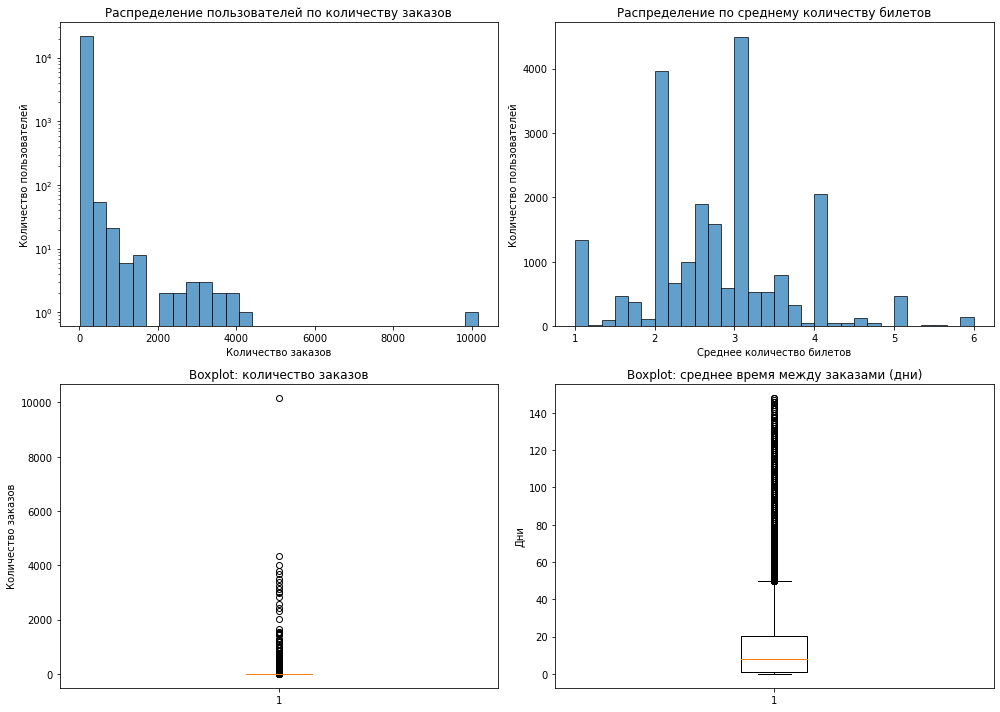


=== АНАЛИЗ АНОМАЛИЙ ===

99-й перцентиль по количеству заказов: 152
Пользователей с количеством заказов выше 99 перцентиля: 219 (1.00%)
Максимальное количество заказов: 10168

99-й перцентиль по среднему количеству билетов: 5.00
Пользователей со средним количеством билетов выше 99 перцентиля: 179 (0.82%)
Максимальное среднее количество билетов: 6.00

После фильтрации осталось пользователей: 21449


In [11]:
print("=== СТАТИСТИКА ПО ПРОФИЛЯМ ПОЛЬЗОВАТЕЛЕЙ ===\n")

# Основные метрики
total_users = len(user_profile)
print(f"1. Общее число пользователей: {total_users:,}".replace(',', ' '))

avg_revenue_per_order = user_profile['avg_revenue_rub'].mean()
print(f"2. Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб.")

repeat_rate_2 = user_profile['is_two'].mean() * 100
print(f"3. Доля пользователей с 2+ заказами: {repeat_rate_2:.2f}%")

repeat_rate_5 = user_profile['is_five'].mean() * 100
print(f"4. Доля пользователей с 5+ заказами: {repeat_rate_5:.2f}%")

print("\n=== СТАТИСТИЧЕСКИЕ ПОКАЗАТЕЛИ ===\n")

# Статистика по общему числу заказов
print("По общему числу заказов (total_orders):")
print(user_profile['total_orders'].describe())

print("\nПо среднему числу билетов (avg_tickets_count):")
print(user_profile['avg_tickets_count'].describe())

print("\nПо среднему времени между заказами (avg_days_between):")
print(user_profile['avg_days_between'].describe())

# Визуализация распределений
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение по количеству заказов
axes[0, 0].hist(user_profile['total_orders'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение пользователей по количеству заказов')
axes[0, 0].set_xlabel('Количество заказов')
axes[0, 0].set_ylabel('Количество пользователей')
axes[0, 0].set_yscale('log')  # логарифмическая шкала из-за сильного перекоса

# Распределение по среднему количеству билетов
axes[0, 1].hist(user_profile['avg_tickets_count'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Распределение по среднему количеству билетов')
axes[0, 1].set_xlabel('Среднее количество билетов')
axes[0, 1].set_ylabel('Количество пользователей')

# Boxplot по количеству заказов
axes[1, 0].boxplot(user_profile['total_orders'])
axes[1, 0].set_title('Boxplot: количество заказов')
axes[1, 0].set_ylabel('Количество заказов')

# Boxplot по среднему времени между заказами
axes[1, 1].boxplot(user_profile['avg_days_between'].dropna())
axes[1, 1].set_title('Boxplot: среднее время между заказами (дни)')
axes[1, 1].set_ylabel('Дни')

plt.tight_layout()
plt.show()

# Анализ на аномалии
print("\n=== АНАЛИЗ АНОМАЛИЙ ===\n")

# Проверка на аномально высокое количество заказов
percentile_99_orders = user_profile['total_orders'].quantile(0.99)
print(f"99-й перцентиль по количеству заказов: {percentile_99_orders:.0f}")

outliers_orders = user_profile[user_profile['total_orders'] > percentile_99_orders]
print(f"Пользователей с количеством заказов выше 99 перцентиля: {len(outliers_orders)} ({len(outliers_orders)/total_users*100:.2f}%)")
print(f"Максимальное количество заказов: {user_profile['total_orders'].max()}")

# Проверка на аномально высокое среднее количество билетов
percentile_99_tickets = user_profile['avg_tickets_count'].quantile(0.99)
print(f"\n99-й перцентиль по среднему количеству билетов: {percentile_99_tickets:.2f}")

outliers_tickets = user_profile[user_profile['avg_tickets_count'] > percentile_99_tickets]
print(f"Пользователей со средним количеством билетов выше 99 перцентиля: {len(outliers_tickets)} ({len(outliers_tickets)/total_users*100:.2f}%)")
print(f"Максимальное среднее количество билетов: {user_profile['avg_tickets_count'].max():.2f}")

# Если есть аномалии, можно отфильтровать
user_profile = user_profile[user_profile['total_orders'] <= percentile_99_orders].copy()
user_profile = user_profile[user_profile['avg_tickets_count'] <= percentile_99_tickets].copy()
print(f"\nПосле фильтрации осталось пользователей: {len(user_profile)}")

---

##  Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



### Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


=== РАСПРЕДЕЛЕНИЕ ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ ===

  Тип мероприятия  Количество пользователей  Доля %
0        концерты                      9514   44.36
1          другое                      5355   24.97
2           театр                      4189   19.53
3         стендап                      1098    5.12
4           спорт                       784    3.66
5        выставки                       414    1.93
6            ёлки                        95    0.44


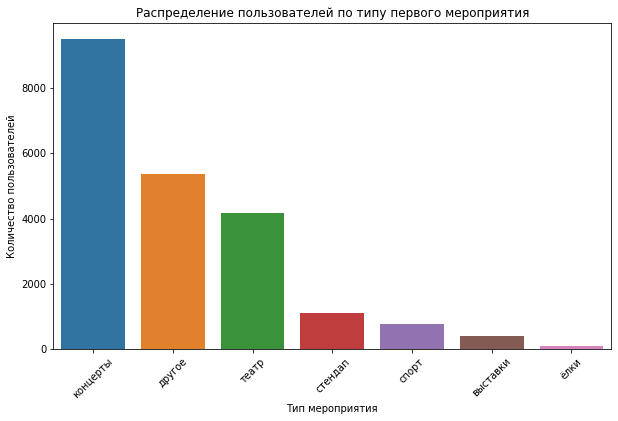


=== РАСПРЕДЕЛЕНИЕ ПО ТИПУ УСТРОЙСТВА ===

  Тип устройства  Количество пользователей  Доля %
0         mobile                     17752   82.76
1        desktop                      3697   17.24


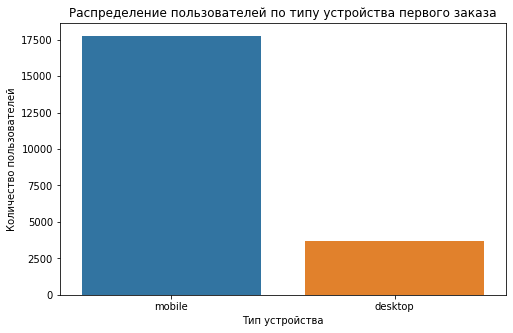


=== РАСПРЕДЕЛЕНИЕ ПО РЕГИОНУ (ТОП-15) ===

                  Регион  Количество пользователей  Доля %
0     Каменевский регион                      7034   32.79
1   Североярская область                      3718   17.33
2    Широковская область                      1209    5.64
3       Озернинский край                       673    3.14
4   Малиновоярский округ                       522    2.43
5       Шанырский регион                       498    2.32
6       Травяная область                       483    2.25
7   Светополянский округ                       454    2.12
8    Речиновская область                       435    2.03
9    Яблоневская область                       406    1.89
10   Верхоречная область                       374    1.74
11     Медовская область                       371    1.73
12  Лугоградская область                       356    1.66
13  Серебринская область                       325    1.52
14  Тепляковская область                       319    1.49


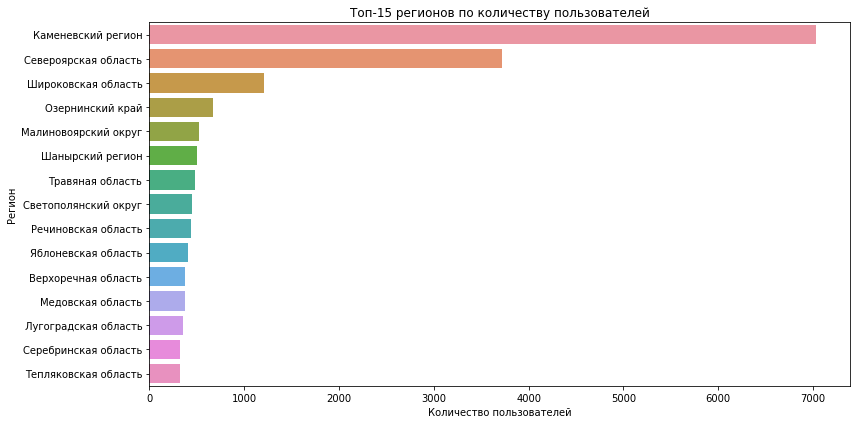


=== РАСПРЕДЕЛЕНИЕ ПО ОПЕРАТОРУ (ТОП-15) ===

                  Оператор  Количество пользователей  Доля %
0       Билеты без проблем                      5102   23.79
1                Мой билет                      2955   13.78
2              Лови билет!                      2783   12.97
3            Билеты в руки                      2542   11.85
4                  Облачко                      2168   10.11
5           Весь в билетах                      1269    5.92
6            Лучшие билеты                      1180    5.50
7                Прачечная                       576    2.69
8             Край билетов                       451    2.10
9             Дом культуры                       353    1.65
10                  Яблоко                       315    1.47
11             Тебе билет!                       305    1.42
12  Городской дом культуры                       215    1.00
13                Мир касс                       206    0.96
14             За билетом!             

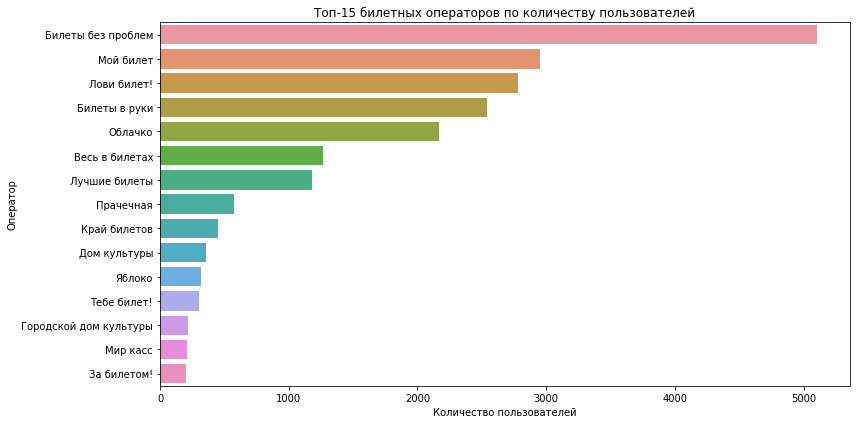

In [12]:
# 1. По типу первого мероприятия
print("=== РАСПРЕДЕЛЕНИЕ ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ ===\n")
event_type_dist = user_profile['first_event_type'].value_counts().reset_index()
event_type_dist.columns = ['Тип мероприятия', 'Количество пользователей']
event_type_dist['Доля %'] = (event_type_dist['Количество пользователей'] / len(user_profile) * 100).round(2)
print(event_type_dist)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=event_type_dist, x='Тип мероприятия', y='Количество пользователей')
plt.title('Распределение пользователей по типу первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.show()

# 2. По типу устройства первого заказа
print("\n=== РАСПРЕДЕЛЕНИЕ ПО ТИПУ УСТРОЙСТВА ===\n")
device_dist = user_profile['first_device'].value_counts().reset_index()
device_dist.columns = ['Тип устройства', 'Количество пользователей']
device_dist['Доля %'] = (device_dist['Количество пользователей'] / len(user_profile) * 100).round(2)
print(device_dist)

# Визуализация
plt.figure(figsize=(8, 5))
sns.barplot(data=device_dist, x='Тип устройства', y='Количество пользователей')
plt.title('Распределение пользователей по типу устройства первого заказа')
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.show()

# 3. По региону первого заказа (топ-15 для наглядности)
print("\n=== РАСПРЕДЕЛЕНИЕ ПО РЕГИОНУ (ТОП-15) ===\n")
region_dist = user_profile['first_region'].value_counts().reset_index()
region_dist.columns = ['Регион', 'Количество пользователей']
region_dist['Доля %'] = (region_dist['Количество пользователей'] / len(user_profile) * 100).round(2)
print(region_dist.head(15))

# Визуализация топ-15 регионов
plt.figure(figsize=(12, 6))
sns.barplot(data=region_dist.head(15), x='Количество пользователей', y='Регион')
plt.title('Топ-15 регионов по количеству пользователей')
plt.xlabel('Количество пользователей')
plt.tight_layout()
plt.show()

# 4. По билетному оператору первого заказа (топ-15)
print("\n=== РАСПРЕДЕЛЕНИЕ ПО ОПЕРАТОРУ (ТОП-15) ===\n")
service_dist = user_profile['first_service'].value_counts().reset_index()
service_dist.columns = ['Оператор', 'Количество пользователей']
service_dist['Доля %'] = (service_dist['Количество пользователей'] / len(user_profile) * 100).round(2)
print(service_dist.head(15))

# Визуализация топ-15 операторов
plt.figure(figsize=(12, 6))
sns.barplot(data=service_dist.head(15), x='Количество пользователей', y='Оператор')
plt.title('Топ-15 билетных операторов по количеству пользователей')
plt.xlabel('Количество пользователей')
plt.tight_layout()
plt.show()

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


=== ВОЗВРАТЫ ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ ===

  first_event_type  total_users  returning_users  return_rate_%
2         концерты         9514             5892          61.93
1           другое         5355             3219          60.11
5            театр         4189             2663          63.57
4          стендап         1098              673          61.29
3            спорт          784              441          56.25
0         выставки          414              266          64.25
6             ёлки           95               53          55.79

Средняя доля возвратов по выборке: 61.57%


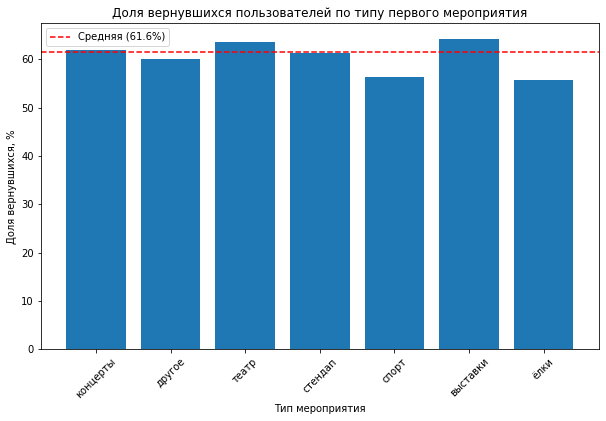


=== ВОЗВРАТЫ ПО ТИПУ УСТРОЙСТВА ===

  first_device  total_users  returning_users  return_rate_%
1       mobile        17752            10829          61.00
0      desktop         3697             2378          64.32


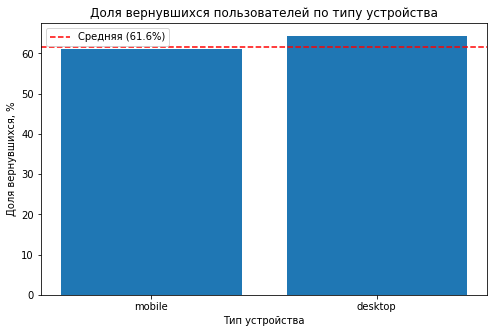


=== ВОЗВРАТЫ ПО РЕГИОНАМ (ТОП-10) ===

            first_region  total_users  returning_users  return_rate_%
23    Каменевский регион         7034             4407          62.65
60  Североярская область         3718             2381          64.04
77   Широковская область         1209              786          65.01
45      Озернинский край          673              375          55.72
41  Малиновоярский округ          522              292          55.94
76      Шанырский регион          498              334          67.07
74      Травяная область          483              298          61.70
57  Светополянский округ          454              298          65.64
52   Речиновская область          435              275          63.22
78   Яблоневская область          406              244          60.10


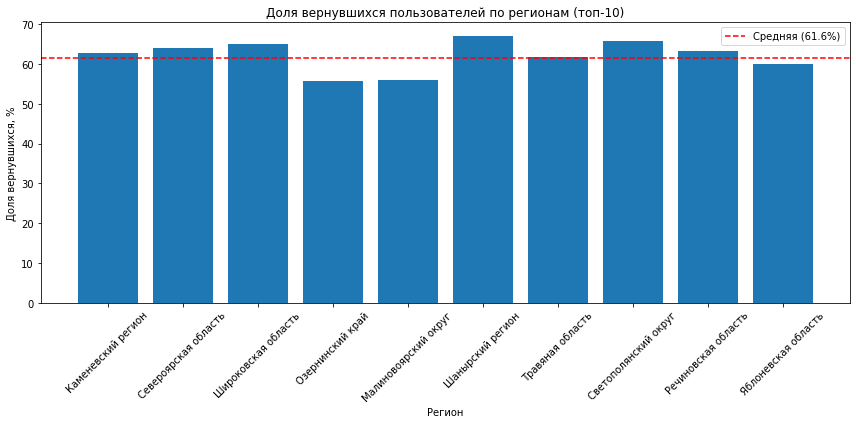


=== ВОЗВРАТЫ ПО ОПЕРАТОРАМ (ТОП-10) ===

         first_service  total_users  returning_users  return_rate_%
3   Билеты без проблем         5102             3097          60.70
22           Мой билет         2955             1802          60.98
19         Лови билет!         2783             1702          61.16
4        Билеты в руки         2542             1600          62.94
23             Облачко         2168             1332          61.44
7       Весь в билетах         1269              798          62.88
20       Лучшие билеты         1180              730          61.86
24           Прачечная          576              361          62.67
17        Край билетов          451              293          64.97
12        Дом культуры          353              230          65.16


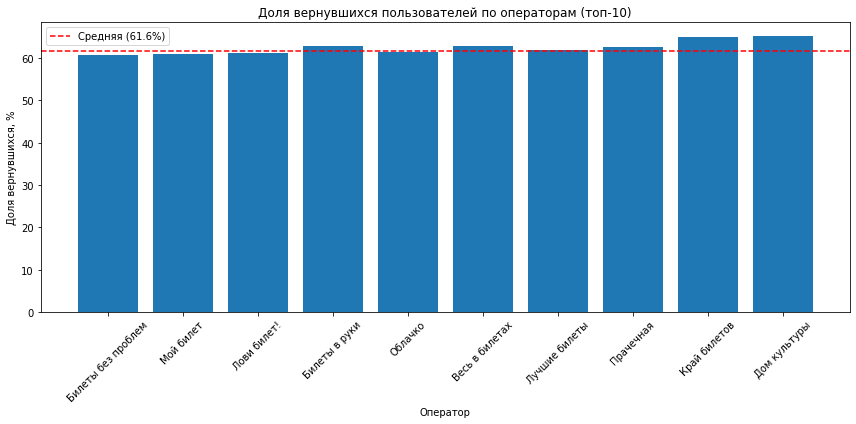

In [13]:
# Функция для анализа возвратов в разрезе категорий
def analyze_returns_by_category(df, category_col, top_n=10):
    # Группируем по категории
    category_stats = df.groupby(category_col).agg(
        total_users=('user_id', 'count'),
        returning_users=('is_two', 'sum')
    ).reset_index()
    
    # Рассчитываем долю вернувшихся
    category_stats['return_rate_%'] = (category_stats['returning_users'] / category_stats['total_users'] * 100).round(2)
    
    # Сортируем по количеству пользователей и берем топ
    category_stats = category_stats.sort_values('total_users', ascending=False).head(top_n)
    
    # Добавляем среднюю долю по выборке для сравнения
    avg_return = df['is_two'].mean() * 100
    
    return category_stats, avg_return

# 1. По типу первого мероприятия
print("=== ВОЗВРАТЫ ПО ТИПУ ПЕРВОГО МЕРОПРИЯТИЯ ===\n")
event_returns, avg_return = analyze_returns_by_category(user_profile, 'first_event_type')
print(event_returns)
print(f"\nСредняя доля возвратов по выборке: {avg_return:.2f}%")

# Визуализация
plt.figure(figsize=(10, 6))
bars = plt.bar(event_returns['first_event_type'], event_returns['return_rate_%'])
plt.axhline(y=avg_return, color='r', linestyle='--', label=f'Средняя ({avg_return:.1f}%)')
plt.title('Доля вернувшихся пользователей по типу первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля вернувшихся, %')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# 2. По типу устройства
print("\n=== ВОЗВРАТЫ ПО ТИПУ УСТРОЙСТВА ===\n")
device_returns, _ = analyze_returns_by_category(user_profile, 'first_device')
print(device_returns)

plt.figure(figsize=(8, 5))
bars = plt.bar(device_returns['first_device'], device_returns['return_rate_%'])
plt.axhline(y=avg_return, color='r', linestyle='--', label=f'Средняя ({avg_return:.1f}%)')
plt.title('Доля вернувшихся пользователей по типу устройства')
plt.xlabel('Тип устройства')
plt.ylabel('Доля вернувшихся, %')
plt.legend()
plt.show()

# 3. По региону (топ-10)
print("\n=== ВОЗВРАТЫ ПО РЕГИОНАМ (ТОП-10) ===\n")
region_returns, _ = analyze_returns_by_category(user_profile, 'first_region', top_n=10)
print(region_returns)

plt.figure(figsize=(12, 6))
bars = plt.bar(region_returns['first_region'], region_returns['return_rate_%'])
plt.axhline(y=avg_return, color='r', linestyle='--', label=f'Средняя ({avg_return:.1f}%)')
plt.title('Доля вернувшихся пользователей по регионам (топ-10)')
plt.xlabel('Регион')
plt.ylabel('Доля вернувшихся, %')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 4. По билетному оператору (топ-10)
print("\n=== ВОЗВРАТЫ ПО ОПЕРАТОРАМ (ТОП-10) ===\n")
service_returns, _ = analyze_returns_by_category(user_profile, 'first_service', top_n=10)
print(service_returns)

plt.figure(figsize=(12, 6))
bars = plt.bar(service_returns['first_service'], service_returns['return_rate_%'])
plt.axhline(y=avg_return, color='r', linestyle='--', label=f'Средняя ({avg_return:.1f}%)')
plt.title('Доля вернувшихся пользователей по операторам (топ-10)')
plt.xlabel('Оператор')
plt.ylabel('Доля вернувшихся, %')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [14]:
print("=== ПРОВЕРКА ГИПОТЕЗ ===\n")

# Гипотеза 1: Спорт vs Концерты
sport_users = user_profile[user_profile['first_event_type'] == 'спорт']
concert_users = user_profile[user_profile['first_event_type'] == 'концерты']

sport_return_rate = sport_users['is_two'].mean() * 100
concert_return_rate = concert_users['is_two'].mean() * 100

print("Гипотеза 1: Спорт vs Концерты")
print(f"Спорт: {len(sport_users)} пользователей, возврат {sport_return_rate:.2f}%")
print(f"Концерты: {len(concert_users)} пользователей, возврат {concert_return_rate:.2f}%")
print(f"Разница: {sport_return_rate - concert_return_rate:.2f}%")

if sport_return_rate > concert_return_rate:
    print("Гипотеза подтверждается: спорт > концерты")
else:
    print("Гипотеза НЕ подтверждается: спорт ≤ концерты")

# Гипотеза 2: Активные регионы vs Остальные
# Определяем топ-5 регионов по количеству пользователей
top_regions = user_profile['first_region'].value_counts().head(5).index.tolist()

active_regions_users = user_profile[user_profile['first_region'].isin(top_regions)]
other_regions_users = user_profile[~user_profile['first_region'].isin(top_regions)]

active_return_rate = active_regions_users['is_two'].mean() * 100
other_return_rate = other_regions_users['is_two'].mean() * 100

print(f"\nГипотеза 2: Топ-5 активных регионов ({', '.join(top_regions)})")
print(f"Активные регионы: {len(active_regions_users)} пользователей, возврат {active_return_rate:.2f}%")
print(f"Остальные регионы: {len(other_regions_users)} пользователей, возврат {other_return_rate:.2f}%")
print(f"Разница: {active_return_rate - other_return_rate:.2f}%")

if active_return_rate > other_return_rate:
    print("Гипотеза подтверждается: в активных регионах возврат выше")
else:
    print("Гипотеза НЕ подтверждается: в активных регионах возврат не выше")

# Дополнительно: проверим все регионы по возвратам
region_return_full = user_profile.groupby('first_region').agg(
    total_users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()
region_return_full['return_rate'] = region_return_full['return_rate'] * 100

# Топ-10 регионов с наибольшим возвратом (где достаточно пользователей)
region_return_full = region_return_full[region_return_full['total_users'] >= 50].sort_values('return_rate', ascending=False)

print("\n=== ТОП-10 РЕГИОНОВ ПО ДОЛЕ ВОЗВРАТОВ (мин. 50 пользователей) ===\n")
print(region_return_full.head(10))

=== ПРОВЕРКА ГИПОТЕЗ ===

Гипотеза 1: Спорт vs Концерты
Спорт: 784 пользователей, возврат 56.25%
Концерты: 9514 пользователей, возврат 61.93%
Разница: -5.68%
Гипотеза НЕ подтверждается: спорт ≤ концерты

Гипотеза 2: Топ-5 активных регионов (Каменевский регион, Североярская область, Широковская область, Озернинский край, Малиновоярский округ)
Активные регионы: 13156 пользователей, возврат 62.64%
Остальные регионы: 8293 пользователей, возврат 59.88%
Разница: 2.76%
Гипотеза подтверждается: в активных регионах возврат выше

=== ТОП-10 РЕГИОНОВ ПО ДОЛЕ ВОЗВРАТОВ (мин. 50 пользователей) ===

            first_region  total_users  return_rate
36      Лесостепной край           59        72.88
79  Ягодиновская область           64        67.19
76      Шанырский регион          498        67.07
11  Горицветская область          241        66.80
54       Речицкий регион          195        65.64
57  Светополянский округ          454        65.64
2    Берёзовская область          118        65.25

---

### Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


=== СРАВНЕНИЕ ГРУПП ПОЛЬЗОВАТЕЛЕЙ ===

Пользователей с 1 заказом: 8242 (38.4%)
Вернувшихся пользователей (2+ заказа): 13207 (61.6%)

Средняя выручка (1 заказ): 541.69 руб.
Средняя выручка (2+ заказа): 542.67 руб.


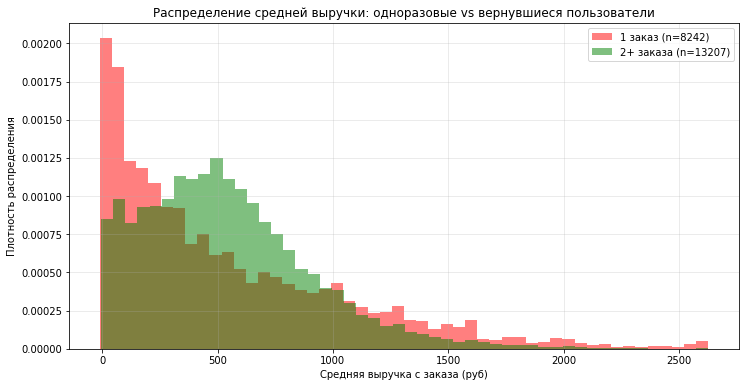


=== АНАЛИЗ ПО ДИАПАЗОНАМ ВЫРУЧКИ ===

Распределение пользователей по диапазонам выручки:
  revenue_category  total_users  one_time_users  returning_users  \
0            0-250         6074            3078             2996   
1          250-500         5278            1638             3640   
2          500-750         4365            1081             3284   
3         750-1000         2625             816             1809   
4        1000-1500         2201            1009             1192   
5        1500-2000          566             363              203   
6            2000+          187             147               40   

   return_rate_%  доля_от_всех  
0          49.32         28.32  
1          68.97         24.61  
2          75.23         20.35  
3          68.91         12.24  
4          54.16         10.26  
5          35.87          2.64  
6          21.39          0.87  


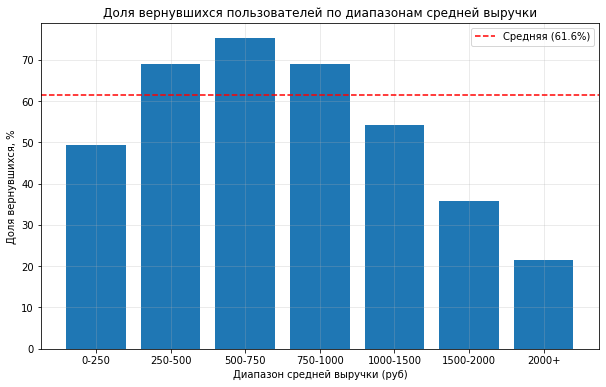

In [15]:
# Разделяем пользователей на две группы
one_time_users = user_profile[user_profile['total_orders'] == 1]
returning_users = user_profile[user_profile['total_orders'] >= 2]

print("=== СРАВНЕНИЕ ГРУПП ПОЛЬЗОВАТЕЛЕЙ ===\n")
print(f"Пользователей с 1 заказом: {len(one_time_users)} ({len(one_time_users)/len(user_profile)*100:.1f}%)")
print(f"Вернувшихся пользователей (2+ заказа): {len(returning_users)} ({len(returning_users)/len(user_profile)*100:.1f}%)")

# Статистика по группам
print(f"\nСредняя выручка (1 заказ): {one_time_users['avg_revenue_rub'].mean():.2f} руб.")
print(f"Средняя выручка (2+ заказа): {returning_users['avg_revenue_rub'].mean():.2f} руб.")

# Сравнительные гистограммы
plt.figure(figsize=(12, 6))

# Используем density=True для сравнения форм распределения
plt.hist(one_time_users['avg_revenue_rub'], bins=50, alpha=0.5, density=True, 
         label=f'1 заказ (n={len(one_time_users)})', color='red')
plt.hist(returning_users['avg_revenue_rub'], bins=50, alpha=0.5, density=True, 
         label=f'2+ заказа (n={len(returning_users)})', color='green')

plt.title('Распределение средней выручки: одноразовые vs вернувшиеся пользователи')
plt.xlabel('Средняя выручка с заказа (руб)')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Более детальный анализ по диапазонам
print("\n=== АНАЛИЗ ПО ДИАПАЗОНАМ ВЫРУЧКИ ===\n")

# Создаем категории выручки
bins = [0, 250, 500, 750, 1000, 1500, 2000, 3000]
labels = ['0-250', '250-500', '500-750', '750-1000', '1000-1500', '1500-2000', '2000+']

user_profile['revenue_category'] = pd.cut(user_profile['avg_revenue_rub'], bins=bins, labels=labels)

# Анализ по категориям
revenue_analysis = user_profile.groupby('revenue_category').agg(
    total_users=('user_id', 'count'),
    one_time_users=('is_two', lambda x: (x == 0).sum()),
    returning_users=('is_two', 'sum')
).reset_index()

revenue_analysis['return_rate_%'] = (revenue_analysis['returning_users'] / revenue_analysis['total_users'] * 100).round(2)
revenue_analysis['доля_от_всех'] = (revenue_analysis['total_users'] / len(user_profile) * 100).round(2)

print("Распределение пользователей по диапазонам выручки:")
print(revenue_analysis)

# Визуализация доли возвратов по диапазонам
plt.figure(figsize=(10, 6))
bars = plt.bar(revenue_analysis['revenue_category'], revenue_analysis['return_rate_%'])
plt.axhline(y=user_profile['is_two'].mean()*100, color='r', linestyle='--', 
            label=f'Средняя ({user_profile["is_two"].mean()*100:.1f}%)')
plt.title('Доля вернувшихся пользователей по диапазонам средней выручки')
plt.xlabel('Диапазон средней выручки (руб)')
plt.ylabel('Доля вернувшихся, %')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


=== СРАВНЕНИЕ ГРУПП: 2-4 ЗАКАЗА VS 5+ ЗАКАЗОВ ===

Пользователей с 2-4 заказами: 7098 (33.1%)
Пользователей с 5+ заказами: 6109 (28.5%)

Средняя выручка (2-4 заказа): 549.23 руб.
Средняя выручка (5+ заказов): 535.06 руб.
Медианная выручка (2-4 заказа): 470.66 руб.
Медианная выручка (5+ заказов): 512.09 руб.


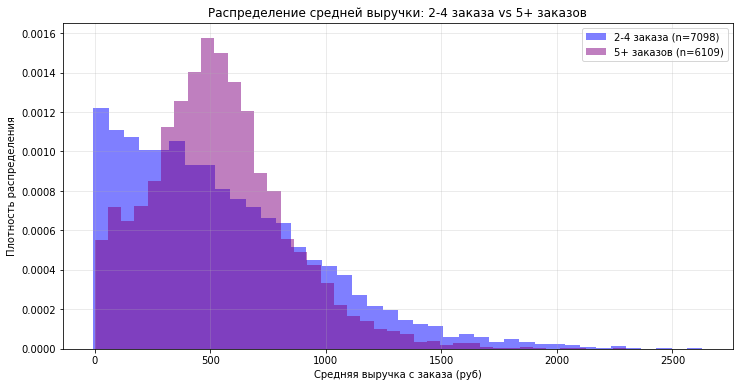

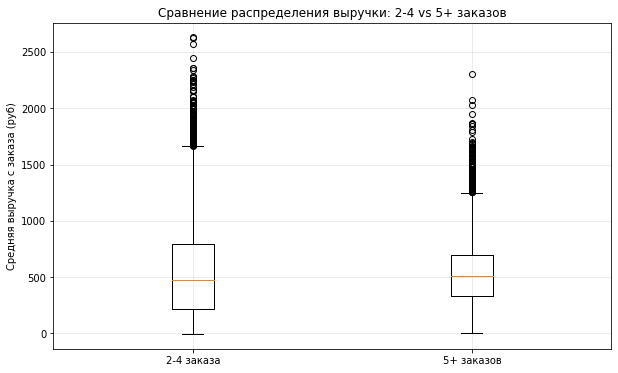

In [16]:
# Разделяем вернувшихся пользователей на две подгруппы
medium_users = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
heavy_users = user_profile[user_profile['total_orders'] >= 5]

print("=== СРАВНЕНИЕ ГРУПП: 2-4 ЗАКАЗА VS 5+ ЗАКАЗОВ ===\n")
print(f"Пользователей с 2-4 заказами: {len(medium_users)} ({len(medium_users)/len(user_profile)*100:.1f}%)")
print(f"Пользователей с 5+ заказами: {len(heavy_users)} ({len(heavy_users)/len(user_profile)*100:.1f}%)")

# Статистика по группам
print(f"\nСредняя выручка (2-4 заказа): {medium_users['avg_revenue_rub'].mean():.2f} руб.")
print(f"Средняя выручка (5+ заказов): {heavy_users['avg_revenue_rub'].mean():.2f} руб.")
print(f"Медианная выручка (2-4 заказа): {medium_users['avg_revenue_rub'].median():.2f} руб.")
print(f"Медианная выручка (5+ заказов): {heavy_users['avg_revenue_rub'].median():.2f} руб.")

# Сравнительные гистограммы
plt.figure(figsize=(12, 6))

plt.hist(medium_users['avg_revenue_rub'], bins=40, alpha=0.5, density=True, 
         label=f'2-4 заказа (n={len(medium_users)})', color='blue')
plt.hist(heavy_users['avg_revenue_rub'], bins=40, alpha=0.5, density=True, 
         label=f'5+ заказов (n={len(heavy_users)})', color='purple')

plt.title('Распределение средней выручки: 2-4 заказа vs 5+ заказов')
plt.xlabel('Средняя выручка с заказа (руб)')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Boxplot для сравнения
plt.figure(figsize=(10, 6))
data_to_plot = [medium_users['avg_revenue_rub'], heavy_users['avg_revenue_rub']]
plt.boxplot(data_to_plot, labels=['2-4 заказа', '5+ заказов'])
plt.title('Сравнение распределения выручки: 2-4 vs 5+ заказов')
plt.ylabel('Средняя выручка с заказа (руб)')
plt.grid(True, alpha=0.3)
plt.show()

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

=== РАСПРЕДЕЛЕНИЕ ПО СРЕДНЕМУ КОЛИЧЕСТВУ БИЛЕТОВ ===

Статистика по avg_tickets_count:
count   21449.00
mean        2.71
std         0.86
min         1.00
25%         2.00
50%         2.75
75%         3.00
max         5.00
Name: avg_tickets_count, dtype: float64


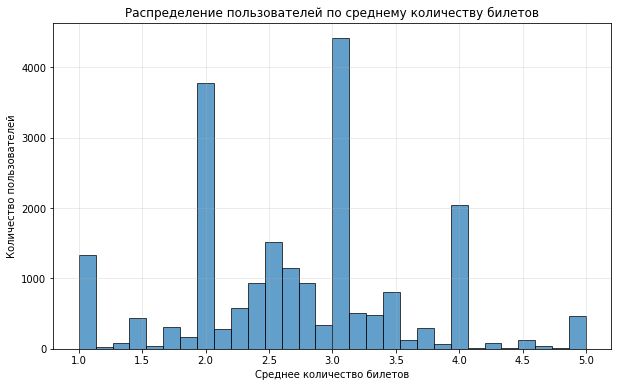


=== АНАЛИЗ ПО СЕГМЕНТАМ КОЛИЧЕСТВА БИЛЕТОВ ===

  tickets_segment  total_users  returning_users  return_rate_%  доля_от_всех_%
0      1-2 билета         2420             1242          51.32           11.28
1      2-3 билета         9502             6993          73.60           44.30
2     3-5 билетов         9058             4911          54.22           42.23
3      5+ билетов          469               61          13.01            2.19


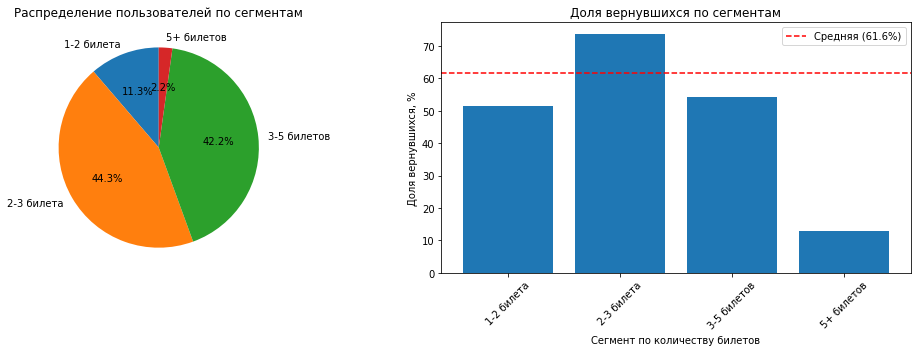


=== ДЕТАЛЬНЫЙ АНАЛИЗ СЕГМЕНТА 5+ БИЛЕТОВ ===

Пользователей в сегменте: 469
Из них вернулись: 61 (13.01%)

Статистика по выручке в этом сегменте:
count    469.00
mean     852.47
std      702.78
min        0.00
25%      253.42
50%      657.56
75%     1364.21
max     2613.15
Name: avg_revenue_rub, dtype: float64


In [17]:
print("=== РАСПРЕДЕЛЕНИЕ ПО СРЕДНЕМУ КОЛИЧЕСТВУ БИЛЕТОВ ===\n")

# Общее распределение
print("Статистика по avg_tickets_count:")
print(user_profile['avg_tickets_count'].describe())

# Гистограмма распределения
plt.figure(figsize=(10, 6))
plt.hist(user_profile['avg_tickets_count'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Распределение пользователей по среднему количеству билетов')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.show()

# Создаем сегменты по количеству билетов
bins_tickets = [0, 2, 3, 5, float('inf')]
labels_tickets = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

user_profile['tickets_segment'] = pd.cut(user_profile['avg_tickets_count'], 
                                         bins=bins_tickets, 
                                         labels=labels_tickets, 
                                         right=False)

# Анализ по сегментам
tickets_analysis = user_profile.groupby('tickets_segment').agg(
    total_users=('user_id', 'count'),
    returning_users=('is_two', 'sum')
).reset_index()

tickets_analysis['return_rate_%'] = (tickets_analysis['returning_users'] / tickets_analysis['total_users'] * 100).round(2)
tickets_analysis['доля_от_всех_%'] = (tickets_analysis['total_users'] / len(user_profile) * 100).round(2)

print("\n=== АНАЛИЗ ПО СЕГМЕНТАМ КОЛИЧЕСТВА БИЛЕТОВ ===\n")
print(tickets_analysis)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение пользователей по сегментам
axes[0].pie(tickets_analysis['total_users'], labels=tickets_analysis['tickets_segment'], 
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Распределение пользователей по сегментам')

# Доля возвратов по сегментам
bars = axes[1].bar(tickets_analysis['tickets_segment'], tickets_analysis['return_rate_%'])
axes[1].axhline(y=user_profile['is_two'].mean()*100, color='r', linestyle='--', 
                label=f'Средняя ({user_profile["is_two"].mean()*100:.1f}%)')
axes[1].set_title('Доля вернувшихся по сегментам')
axes[1].set_xlabel('Сегмент по количеству билетов')
axes[1].set_ylabel('Доля вернувшихся, %')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Детальный анализ для сегмента 5+ билетов (проверка на аномалии)
high_tickets = user_profile[user_profile['tickets_segment'] == '5+ билетов']
print(f"\n=== ДЕТАЛЬНЫЙ АНАЛИЗ СЕГМЕНТА 5+ БИЛЕТОВ ===\n")
print(f"Пользователей в сегменте: {len(high_tickets)}")
print(f"Из них вернулись: {high_tickets['is_two'].sum()} ({high_tickets['is_two'].mean()*100:.2f}%)")
print(f"\nСтатистика по выручке в этом сегменте:")
print(high_tickets['avg_revenue_rub'].describe())

---

### Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


=== АНАЛИЗ ПО ДНЯМ НЕДЕЛИ ПЕРВОГО ЗАКАЗА ===

    weekday_ru  total_users  return_rate_%  доля_от_всех_%
0  Понедельник         2906          63.18           13.55
1      Вторник         3148          62.07           14.68
2        Среда         3028          62.45           14.12
3      Четверг         3087          59.64           14.39
4      Пятница         3236          60.14           15.09
5      Суббота         3295          63.03           15.36
6  Воскресенье         2749          60.46           12.82


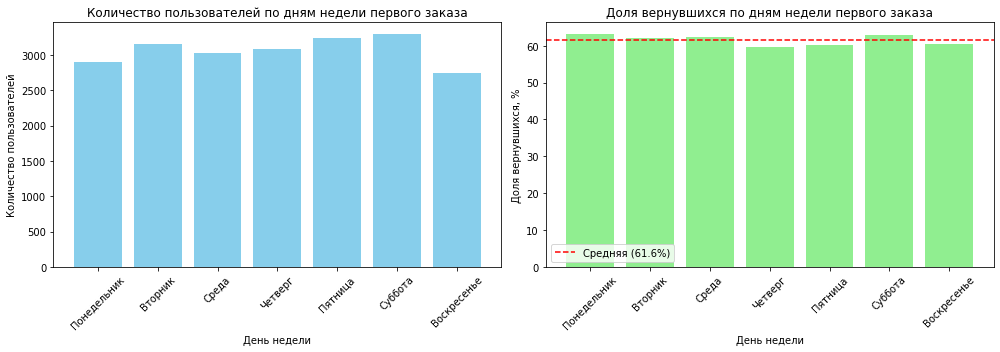

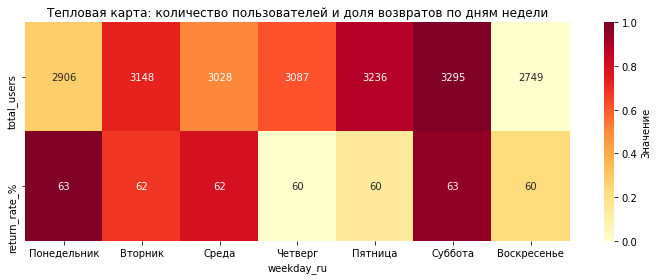


=== ВЫВОД ПО ДНЯМ НЕДЕЛИ ===

Максимальное число первых заказов: Суббота (3295 пользователей)
Минимальное число первых заказов: Воскресенье (2749 пользователей)
Максимальная доля возвратов: Понедельник (63.18%)
Минимальная доля возвратов: Четверг (59.64%)


In [18]:
# Создаем копию профиля для работы
user_profile_week = user_profile.copy()

# Преобразуем first_order_dt в datetime, если еще не
user_profile_week['first_order_dt'] = pd.to_datetime(user_profile_week['first_order_dt'])

# Извлекаем день недели (0 = понедельник, 6 = воскресенье)
user_profile_week['weekday'] = user_profile_week['first_order_dt'].dt.dayofweek
user_profile_week['weekday_name'] = user_profile_week['first_order_dt'].dt.day_name()

# Словарь для русских названий дней
weekday_names_ru = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}
user_profile_week['weekday_ru'] = user_profile_week['weekday'].map(weekday_names_ru)

# Анализ по дням недели
weekday_analysis = user_profile_week.groupby(['weekday', 'weekday_ru']).agg(
    total_users=('user_id', 'count'),
    returning_users=('is_two', 'sum')
).reset_index()

# Сортируем по дню недели
weekday_analysis = weekday_analysis.sort_values('weekday')

weekday_analysis['return_rate_%'] = (weekday_analysis['returning_users'] / weekday_analysis['total_users'] * 100).round(2)
weekday_analysis['доля_от_всех_%'] = (weekday_analysis['total_users'] / len(user_profile_week) * 100).round(2)

print("=== АНАЛИЗ ПО ДНЯМ НЕДЕЛИ ПЕРВОГО ЗАКАЗА ===\n")
print(weekday_analysis[['weekday_ru', 'total_users', 'return_rate_%', 'доля_от_всех_%']])

# Визуализация 1: Количество пользователей по дням недели
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График количества пользователей
axes[0].bar(weekday_analysis['weekday_ru'], weekday_analysis['total_users'], color='skyblue')
axes[0].set_title('Количество пользователей по дням недели первого заказа')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество пользователей')
axes[0].tick_params(axis='x', rotation=45)

# График доли возвратов
bars = axes[1].bar(weekday_analysis['weekday_ru'], weekday_analysis['return_rate_%'], color='lightgreen')
axes[1].axhline(y=user_profile['is_two'].mean()*100, color='r', linestyle='--', 
                label=f'Средняя ({user_profile["is_two"].mean()*100:.1f}%)')
axes[1].set_title('Доля вернувшихся по дням недели первого заказа')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Доля вернувшихся, %')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# Дополнительная визуализация: тепловая карта по дням недели
plt.figure(figsize=(10, 4))
# Создаем матрицу для тепловой карты
heatmap_data = weekday_analysis.set_index('weekday_ru')[['total_users', 'return_rate_%']]
# Нормализуем для лучшего отображения
heatmap_data_normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

sns.heatmap(heatmap_data_normalized.T, annot=heatmap_data.T, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Значение'})
plt.title('Тепловая карта: количество пользователей и доля возвратов по дням недели')
plt.tight_layout()
plt.show()

print("\n=== ВЫВОД ПО ДНЯМ НЕДЕЛИ ===\n")
print(f"Максимальное число первых заказов: {weekday_analysis.loc[weekday_analysis['total_users'].idxmax(), 'weekday_ru']} "
      f"({weekday_analysis['total_users'].max()} пользователей)")
print(f"Минимальное число первых заказов: {weekday_analysis.loc[weekday_analysis['total_users'].idxmin(), 'weekday_ru']} "
      f"({weekday_analysis['total_users'].min()} пользователей)")
print(f"Максимальная доля возвратов: {weekday_analysis.loc[weekday_analysis['return_rate_%'].idxmax(), 'weekday_ru']} "
      f"({weekday_analysis['return_rate_%'].max():.2f}%)")
print(f"Минимальная доля возвратов: {weekday_analysis.loc[weekday_analysis['return_rate_%'].idxmin(), 'weekday_ru']} "
      f"({weekday_analysis['return_rate_%'].min():.2f}%)")

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


=== АНАЛИЗ СРЕДНЕГО ИНТЕРВАЛА МЕЖДУ ЗАКАЗАМИ ===

Пользователей с 2-4 заказами (с данными об интервалах): 7098
Пользователей с 5+ заказами (с данными об интервалах): 6109

Средний интервал (2-4 заказа): 21.51 дней
Средний интервал (5+ заказов): 9.98 дней
Медианный интервал (2-4 заказа): 9.17 дней
Медианный интервал (5+ заказов): 8.23 дней


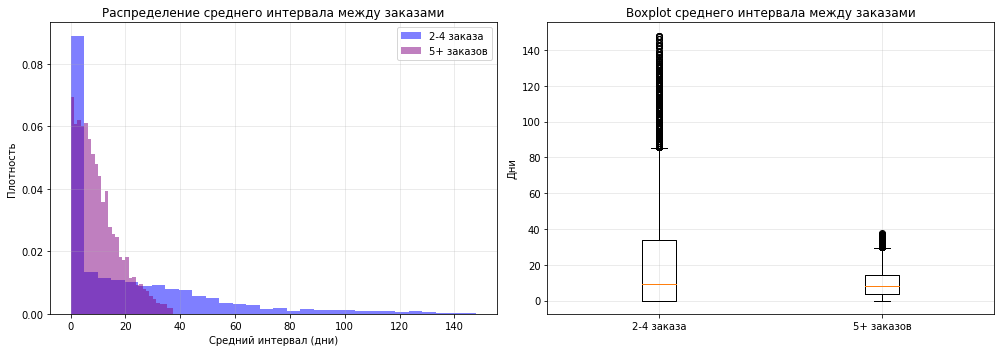


=== КОРРЕЛЯЦИЯ ИНТЕРВАЛА С КОЛИЧЕСТВОМ ЗАКАЗОВ ===

Корреляция между интервалом и количеством заказов: -0.213
Слабая отрицательная связь

=== АНАЛИЗ ПО ДИАПАЗОНАМ ИНТЕРВАЛОВ ===

Распределение пользователей по диапазонам интервалов:
  interval_category  total_users  avg_orders  доля_пользователей_%
0          0-7 дней         3341       24.64                 25.30
1         8-14 дней         2468        8.99                 18.69
2        15-30 дней         2556        5.10                 19.35
3        31-60 дней         1455        3.09                 11.02
4          60+ дней          700        2.15                  5.30


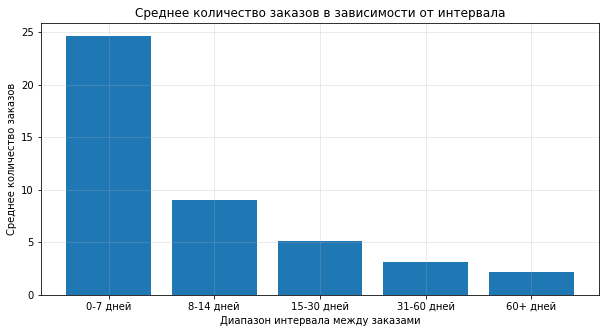

In [19]:
# Задача 4.3.2: Анализ среднего интервала между заказами

# Используем только пользователей с повторными заказами (у кого есть avg_days_between)
users_with_intervals = user_profile[user_profile['avg_days_between'].notna()].copy()

# Разделяем на группы
medium_users_interval = users_with_intervals[(users_with_intervals['total_orders'] >= 2) & 
                                             (users_with_intervals['total_orders'] <= 4)]
heavy_users_interval = users_with_intervals[users_with_intervals['total_orders'] >= 5]

print("=== АНАЛИЗ СРЕДНЕГО ИНТЕРВАЛА МЕЖДУ ЗАКАЗАМИ ===\n")
print(f"Пользователей с 2-4 заказами (с данными об интервалах): {len(medium_users_interval)}")
print(f"Пользователей с 5+ заказами (с данными об интервалах): {len(heavy_users_interval)}")

# Статистика по интервалам
print(f"\nСредний интервал (2-4 заказа): {medium_users_interval['avg_days_between'].mean():.2f} дней")
print(f"Средний интервал (5+ заказов): {heavy_users_interval['avg_days_between'].mean():.2f} дней")
print(f"Медианный интервал (2-4 заказа): {medium_users_interval['avg_days_between'].median():.2f} дней")
print(f"Медианный интервал (5+ заказов): {heavy_users_interval['avg_days_between'].median():.2f} дней")

# Визуализация распределения интервалов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограммы
axes[0].hist(medium_users_interval['avg_days_between'], bins=30, alpha=0.5, density=True, 
             label=f'2-4 заказа', color='blue')
axes[0].hist(heavy_users_interval['avg_days_between'], bins=30, alpha=0.5, density=True, 
             label=f'5+ заказов', color='purple')
axes[0].set_title('Распределение среднего интервала между заказами')
axes[0].set_xlabel('Средний интервал (дни)')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
data_to_plot = [medium_users_interval['avg_days_between'], heavy_users_interval['avg_days_between']]
axes[1].boxplot(data_to_plot, labels=['2-4 заказа', '5+ заказов'])
axes[1].set_title('Boxplot среднего интервала между заказами')
axes[1].set_ylabel('Дни')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ корреляции интервала с количеством заказов
print("\n=== КОРРЕЛЯЦИЯ ИНТЕРВАЛА С КОЛИЧЕСТВОМ ЗАКАЗОВ ===\n")
correlation = users_with_intervals[['avg_days_between', 'total_orders']].corr().iloc[0,1]
print(f"Корреляция между интервалом и количеством заказов: {correlation:.3f}")

if correlation < -0.3:
    print("Сильная отрицательная связь: чем меньше интервал, тем больше заказов")
elif correlation < -0.1:
    print("Слабая отрицательная связь")
elif correlation < 0.1:
    print("Связь практически отсутствует")
elif correlation < 0.3:
    print("Слабая положительная связь")
else:
    print("Сильная положительная связь")

# Анализ по диапазонам интервалов
print("\n=== АНАЛИЗ ПО ДИАПАЗОНАМ ИНТЕРВАЛОВ ===\n")

bins_interval = [0, 7, 14, 30, 60, float('inf')]
labels_interval = ['0-7 дней', '8-14 дней', '15-30 дней', '31-60 дней', '60+ дней']

users_with_intervals['interval_category'] = pd.cut(users_with_intervals['avg_days_between'], 
                                                   bins=bins_interval, 
                                                   labels=labels_interval)

interval_analysis = users_with_intervals.groupby('interval_category').agg(
    total_users=('user_id', 'count'),
    avg_orders=('total_orders', 'mean')
).reset_index()

interval_analysis['доля_пользователей_%'] = (interval_analysis['total_users'] / len(users_with_intervals) * 100).round(2)

print("Распределение пользователей по диапазонам интервалов:")
print(interval_analysis)

# Визуализация
plt.figure(figsize=(10, 5))
bars = plt.bar(interval_analysis['interval_category'], interval_analysis['avg_orders'])
plt.title('Среднее количество заказов в зависимости от интервала')
plt.xlabel('Диапазон интервала между заказами')
plt.ylabel('Среднее количество заказов')
plt.grid(True, alpha=0.3)
plt.show()

---

### Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [22]:
# Устанавливаем библиотеку phik
!pip install phik

# Теперь импортируем
import phik
from phik import resources, report
import warnings
warnings.filterwarnings('ignore')

     |████████████████████████████████| 677 kB 2.1 MB/s eta 0:00:01
Библиотека phik успешно установлена и импортирована!


=== КОРРЕЛЯЦИОННЫЙ АНАЛИЗ PHIK ДЛЯ ВСЕХ ПОЛЬЗОВАТЕЛЕЙ ===

Корреляции признаков с total_orders:
total_orders        1.00
avg_tickets_count   0.39
avg_revenue_rub     0.22
avg_days_between    0.17
first_region        0.12
first_service       0.03
first_event_type    0.03
first_device        0.03
Name: total_orders, dtype: float64


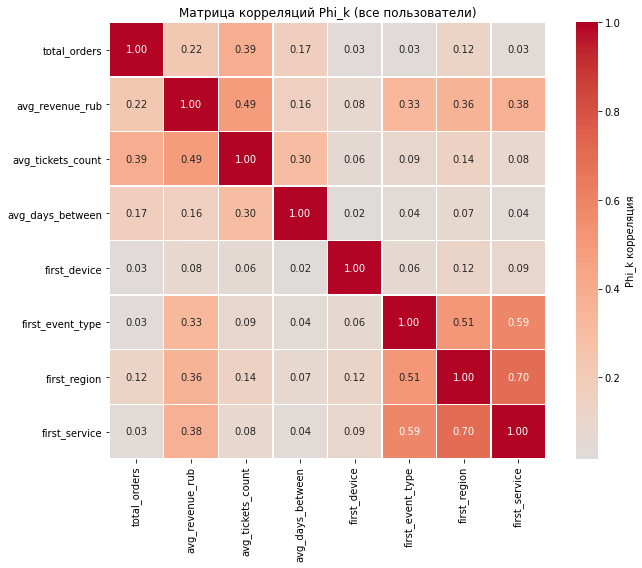


=== АНАЛИЗ ПО СЕГМЕНТАМ ПОЛЬЗОВАТЕЛЕЙ ===

Сегмент 1 заказ: 8242 пользователей
Сегмент 2-4 заказа: 7098 пользователей
Сегмент 5+ заказов: 6109 пользователей

=== КОРРЕЛЯЦИИ В СЕГМЕНТЕ: 1 заказ ===

В сегменте 1 заказ ошибка: 'total_orders'

=== КОРРЕЛЯЦИИ В СЕГМЕНТЕ: 2-4 заказа ===

Корреляции с total_orders:
total_orders        1.00
avg_tickets_count   0.39
avg_days_between    0.39
avg_revenue_rub     0.11
first_service       0.06
first_device        0.01
first_event_type    0.00
first_region        0.00
Name: total_orders, dtype: float64

=== КОРРЕЛЯЦИИ В СЕГМЕНТЕ: 5+ заказов ===

Корреляции с total_orders:
total_orders        1.00
avg_days_between    0.70
avg_tickets_count   0.30
avg_revenue_rub     0.24
first_region        0.18
first_event_type    0.04
first_service       0.03
first_device        0.00
Name: total_orders, dtype: float64


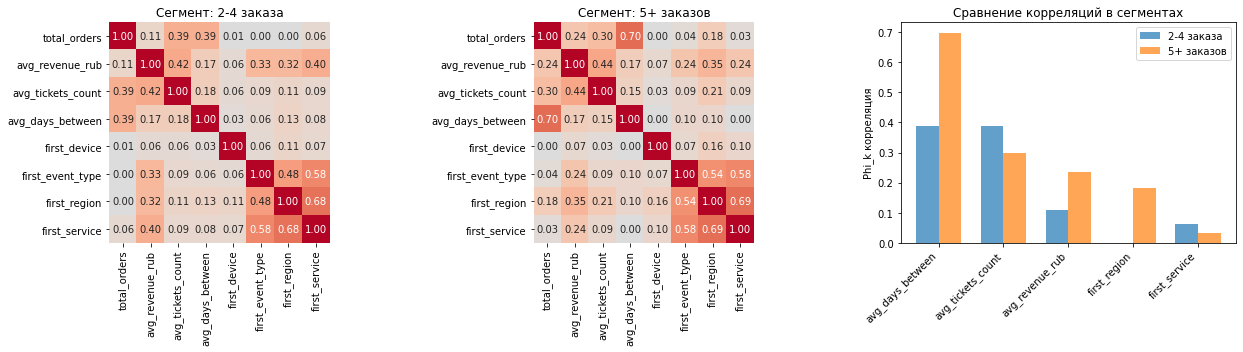

In [24]:
# Подготовка данных для корреляционного анализа
correlation_features = user_profile[[
    'total_orders',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_between',
    'first_device',
    'first_event_type',
    'first_region',
    'first_service'
]].copy()

# Заполняем пропуски в avg_days_between (для пользователей с 1 заказом) значением -1
correlation_features['avg_days_between'] = correlation_features['avg_days_between'].fillna(-1)

print("=== КОРРЕЛЯЦИОННЫЙ АНАЛИЗ PHIK ДЛЯ ВСЕХ ПОЛЬЗОВАТЕЛЕЙ ===\n")

# Рассчитываем матрицу корреляций phik
phik_matrix = correlation_features.phik_matrix(interval_cols=['total_orders', 'avg_revenue_rub', 
                                                              'avg_tickets_count', 'avg_days_between'])

# Извлекаем корреляции с total_orders
correlations_with_orders = phik_matrix['total_orders'].sort_values(ascending=False)
print("Корреляции признаков с total_orders:")
print(correlations_with_orders)

# Визуализация полной матрицы корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Phi_k корреляция'})
plt.title('Матрица корреляций Phi_k (все пользователи)')
plt.tight_layout()
plt.show()

print("\n=== АНАЛИЗ ПО СЕГМЕНТАМ ПОЛЬЗОВАТЕЛЕЙ ===\n")

# Создаем сегменты по total_orders
segment_1 = user_profile[user_profile['total_orders'] == 1].copy()
segment_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)].copy()
segment_5plus = user_profile[user_profile['total_orders'] >= 5].copy()

print(f"Сегмент 1 заказ: {len(segment_1)} пользователей")
print(f"Сегмент 2-4 заказа: {len(segment_2_4)} пользователей")
print(f"Сегмент 5+ заказов: {len(segment_5plus)} пользователей")

# Функция для анализа сегмента
def analyze_segment_correlations(segment, segment_name):
    print(f"\n=== КОРРЕЛЯЦИИ В СЕГМЕНТЕ: {segment_name} ===\n")
    
    # Подготавливаем данные
    seg_features = segment[[
        'total_orders',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_between',
        'first_device',
        'first_event_type',
        'first_region',
        'first_service'
    ]].copy()
    
    # Заполняем пропуски в avg_days_between
    seg_features['avg_days_between'] = seg_features['avg_days_between'].fillna(-1)
    
    # Рассчитываем корреляции
    try:
        seg_phik = seg_features.phik_matrix(interval_cols=['total_orders', 'avg_revenue_rub', 
                                                            'avg_tickets_count', 'avg_days_between'])
        seg_corr = seg_phik['total_orders'].sort_values(ascending=False)
        print("Корреляции с total_orders:")
        print(seg_corr)
        return seg_phik
    except Exception as e:
        print(f"В сегменте {segment_name} ошибка: {e}")
        return None

# Анализируем каждый сегмент
phik_1 = analyze_segment_correlations(segment_1, "1 заказ")
phik_2_4 = analyze_segment_correlations(segment_2_4, "2-4 заказа")
phik_5plus = analyze_segment_correlations(segment_5plus, "5+ заказов")

# Визуализация для сегментов с достаточным количеством данных
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if phik_2_4 is not None:
    sns.heatmap(phik_2_4, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, ax=axes[0], cbar=False)
    axes[0].set_title('Сегмент: 2-4 заказа')

if phik_5plus is not None:
    sns.heatmap(phik_5plus, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, ax=axes[1], cbar=False)
    axes[1].set_title('Сегмент: 5+ заказов')

# Сравнительный график топ-признаков
if phik_2_4 is not None and phik_5plus is not None:
    # Берем топ-5 признаков из каждого сегмента
    top_features = set(phik_2_4['total_orders'].nlargest(5).index) | set(phik_5plus['total_orders'].nlargest(5).index)
    top_features = [f for f in top_features if f != 'total_orders']
    
    comparison_data = []
    for feature in top_features:
        comparison_data.append({
            'Признак': feature,
            '2-4 заказа': phik_2_4.loc[feature, 'total_orders'] if feature in phik_2_4.index else 0,
            '5+ заказов': phik_5plus.loc[feature, 'total_orders'] if feature in phik_5plus.index else 0
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('5+ заказов', ascending=False)
    
    x = range(len(comparison_df))
    width = 0.35
    
    axes[2].bar([i - width/2 for i in x], comparison_df['2-4 заказа'], width, label='2-4 заказа', alpha=0.7)
    axes[2].bar([i + width/2 for i in x], comparison_df['5+ заказов'], width, label='5+ заказов', alpha=0.7)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(comparison_df['Признак'], rotation=45, ha='right')
    axes[2].set_title('Сравнение корреляций в сегментах')
    axes[2].set_ylabel('Phi_k корреляция')
    axes[2].legend()

plt.tight_layout()
plt.show()

## Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

### Информация о данных и предобработка

В ходе проекта был проведён анализ данных Яндекс Афиши за период **лето-осень 2024 года** (июнь-октябрь). 

**Подготовка данных:**
- Выгружено **284 737 заказов** от **21 449 уникальных пользователей** (после всех фильтраций)
- Произведена конвертация валют: заказы в тенге переведены в рубли по актуальному курсу (создан столбец `revenue_rub`)
- Проведена фильтрация выбросов по 99-му перцентилю для `revenue_rub` (удалено ~1% аномально высоких заказов)
- Оптимизированы типы данных для экономии памяти
- Пропуски обнаружены только в поле `days_since_prev` (для первых покупок), что является нормой

### Основные результаты анализа

#### Общая статистика пользователей
- **Всего пользователей:** 21 449
- **Доля вернувшихся (2+ заказа):** 61.6% (13 207 пользователей)
- **Доля постоянных (5+ заказов):** 28.5% (6 109 пользователей)
- **Средняя выручка с заказа:** 542 руб.
- **Среднее количество билетов:** 2.7 шт.
- **Средний интервал между заказами:** 15.9 дней (для вернувшихся)

#### Признаки первого заказа и возвраты

**Тип мероприятия:**
- Выставки (64.3%) и театр (63.6%) — лидеры по возвратам
- Спорт (56.3%) — самый низкий возврат среди основных категорий
- **Гипотеза 1 НЕ подтвердилась:** спорт (56.3%) < концерты (61.9%)

**Тип устройства:**
- Desktop (64.3%) показывает более высокий возврат, чем mobile (61.0%)
- Однако mobile — основная точка входа (82.8% пользователей)

**Регионы:**
- Сильная концентрация: топ-5 регионов — 61% всех пользователей
- **Гипотеза 2 ПОДТВЕРДИЛАСЬ:** в активных регионах возврат выше (62.6% vs 59.9%)
- Регионы-лидеры по возврату: Лесостепной край (72.9%), Ягодиновская область (67.2%)

**Билетные операторы:**
- Топ-5 операторов обслуживают 70% пользователей
- Лидеры по возврату: Дом культуры (65.2%), Край билетов (65.0%)

#### Влияние выручки и количества билетов

**Выручка:**
- Максимальная доля возвратов (75.2%) — в диапазоне 500-750 руб.
- Крайне низкие (<250 руб.) и высокие (>1500 руб.) заказы показывают падение возвратов (<50%)
- U-образная зависимость: оптимальный диапазон 250-1000 руб.

**Количество билетов:**
- Сегмент 2-3 билета — ядро аудитории (44.3% пользователей) с максимальным возвратом 73.6%
- Сегмент 5+ билетов — крайне мал (2.2%) и показывает аномально низкий возврат (13.0%)

#### Временные характеристики

**День недели первого заказа:**
- Пик первых заказов — суббота (3295 пользователей)
- Максимальный возврат — понедельник (63.2%)
- Минимальный возврат — четверг (59.6%)
- Разница между днями достигает 3.5 п.п. — фактор значим

**Интервалы между заказами:**
- Пользователи с 5+ заказами возвращаются в 2 раза быстрее (10 vs 21.5 дней)
- Корреляция интервала с количеством заказов: **-0.21** (слабая отрицательная)
- Чем короче интервал после первой покупки, тем выше вероятность стать постоянным клиентом

#### Корреляционный анализ (Phi_k)

**Факторы, наиболее связанные с количеством заказов:**
1. **avg_tickets_count (0.39)** — среднее количество билетов
2. **avg_revenue_rub (0.22)** — средняя выручка
3. **avg_days_between (0.17)** — средний интервал

**В сегменте 5+ заказов** резко возрастает роль интервала (0.70) — для "супер-постоянных" клиентов критически важна частота покупок.

### Рекомендации для маркетинговой команды

#### На какие сегменты делать ставку (высокий потенциал)

1. **Ядро аудитории (2-3 билета, выручка 500-750 руб.)**
   - Это 44% пользователей с возвратом 74%
   - Рекомендация: разработать программы лояльности для удержания этого сегмента

2. **Desktop-пользователи**
   - Показывают возврат на 3.3 п.п. выше mobile
   - Рекомендация: протестировать персонализированные предложения для desktop-аудитории

3. **Регионы с высоким возвратом** (Лесостепной край, Ягодиновская область, Шанырский регион)
   - Рекомендация: усилить маркетинговое присутствие, изучить успешные практики для масштабирования

4. **Операторы-лидеры** (Дом культуры, Край билетов)
   - Рекомендация: проанализировать их механизмы удержания, рассмотреть коллаборации

#### Требуют дополнительных усилий

1. **Сегмент 5+ билетов**
   - Аномально низкий возврат (13%) при высокой выручке (852 руб.)
   - Вероятно, это корпоративные или групповые заказы
   - Рекомендация: изучить поведение сегмента, возможно, нужны B2B-инструменты

2. **Спортивные мероприятия**
   - Самый низкий возврат среди категорий (56%)
   - Рекомендация: проанализировать причины, возможно, нужны кросс-продажи или комбо-предложения

3. **Крайние диапазоны выручки** (<250 руб. и >1500 руб.)
   - Низкий возврат (<50%)
   - Рекомендация: для "дешевых" заказов — стимулировать повтор через скидки; для "дорогих" — изучать причины однократности

#### Временные рекомендации

1. **Активизировать коммуникацию в первые 7-10 дней после покупки**
   - Именно этот интервал критичен для перехода в категорию "постоянные"

2. **Усилить маркетинг в четверг**
   - Самый низкий возврат — возможно, нужны специальные предложения для покупателей четверга

3. **Использовать понедельник как день "высокого потенциала"**
   - Максимальный возврат — хороший день для тестирования новых механик

#### Персонализация на основе первого заказа

1. **Для новых пользователей из "спорта" и "ёлок"** — предлагать сразу следующий билет со скидкой (низкая базовая лояльность)
2. **Для пользователей с 1-2 билетами** — стимулировать к покупке 3-го билета (переход в ядро)
3. **Для пользователей с интервалом >30 дней** — реактивировать через спецпредложения

---

**Ключевой вывод:** Основной драйвер возвратов — попадание в "золотую середину": 2-3 билета, выручка 500-750 руб., повтор в течение 7-10 дней. Маркетинговые усилия стоит фокусировать на переводе пользователей именно в этот оптимальный диапазон.

## Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**
 Ссылка на репозиторий GitHub
[origin  https://github.com/primos1723/yandex-afisha-analysis]